In [6]:
import torch

# ตรวจสอบและใช้งาน GPU ของชิป M4
device = torch.device("mps") if torch.backends.mps.is_available() else torch.device("cpu")
print(f"รันโมเดลบน: {device}")

รันโมเดลบน: mps


In [7]:
import numpy as np
from scipy.io import loadmat

ai_model = 'cnn'
snr = 0
scenario = 'O1'
frequency = 60
antennas = 64

path = f'../DeepMIMO/DeepMIMO/DeepMIMO_dataset/SNR{snr}dB_{scenario}_{frequency}_Ant{antennas}/'
d1 = loadmat(path+'channel1.mat')['a']
d2 = loadmat(path+'channel2.mat')['b']
d3 = loadmat(path+'channel3.mat')['c']

data = np.concatenate((d1, d2, d3), axis=2).transpose(2, 0, 1)

d_r = data.real.reshape(-1, 1, 64, 32)
d_i = data.imag.reshape(-1, 1, 64, 32)

X = np.concatenate((d_r, d_i), axis=1)
mean = np.mean(X, axis=0)
std = np.std(X, axis=0)
X = (X - mean) / (std + 1e-8) # 1e-8 prevents division by zero

print("Data normalization complete. Features now have Mean ≈ 0 and Std ≈ 1.")

# Load Label (One-hot encoding)
y = loadmat(path+'DLCB_output.mat')['onehot_label']

print(f"Input shape: {X.shape}")
print(f"Label shape: {y.shape}")

Data normalization complete. Features now have Mean ≈ 0 and Std ≈ 1.
Input shape: (53467, 2, 64, 32)
Label shape: (53467, 64)


In [8]:
from torch.utils.data import DataLoader, TensorDataset

split_idx = int(len(X) * 0.7)

# Training set: The first 70% of the user path
X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]

print(f"Data Split Complete:")
print(f" - Training samples: {len(X_train)} (First 70%)")
print(f" - Testing samples:  {len(X_test)} (Last 30% - Future Path)")

train_ds = TensorDataset(torch.tensor(X_train).float(), torch.tensor(y_train).float())
test_ds = TensorDataset(torch.tensor(X_test).float(), torch.tensor(y_test).float())

train_loader = DataLoader(train_ds, batch_size=128, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=128, shuffle=False)

Data Split Complete:
 - Training samples: 37426 (First 70%)
 - Testing samples:  16041 (Last 30% - Future Path)


In [ ]:
import torch
import torch.nn as nn
import numpy as np
import random

def apply_global_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    
    if torch.backends.mps.is_available():
        torch.mps.manual_seed(seed)
        
    print(f"Global environment locked with seed: {seed}")

apply_global_seed(42)

class BeamPredictionCNN(nn.Module):
    def __init__(self, n_beams, dropout_rate=0.2):
        super(BeamPredictionCNN, self).__init__()
        
        self.cnn = nn.Sequential(
            nn.Conv2d(in_channels=2, out_channels=16, kernel_size=3, padding=1, bias=False),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=(4, 2)),
            nn.Dropout(dropout_rate),
            
            nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1, bias=False),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=4),
            nn.Dropout(dropout_rate)
        )
        
        self.linear = nn.Sequential(
            nn.Linear(512, 164),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(164, n_beams)
        )

    def forward(self, x):
        x = self.cnn(x)
        x = x.view(x.size(0), -1)
        x = self.linear(x)
        return x

Global environment locked with seed: 42


In [10]:
model = BeamPredictionCNN(n_beams=64, dropout_rate=0.2).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=5, factor=0.5)
criterion = nn.CrossEntropyLoss()

params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total Trainable Params: {params}')

Total Trainable Params: 100399


In [11]:
epochs = 100
best_loss = float('inf')
train_losses = []

for epoch in range(epochs):
    epoch_loss = 0.0
    model.train()
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(inputs)
        # Use torch.max to find the best index of beam for CrossEntropyLoss
        loss = criterion(outputs, torch.max(labels, 1)[1])
        loss.backward()
        optimizer.step()
        
        epoch_loss += loss.item()
        
    avg_epoch_loss = epoch_loss / len(train_loader)
    train_losses.append(avg_epoch_loss)
        
    scheduler.step(avg_epoch_loss)
        
    if (epoch + 1) % 10 == 0:
        print(f'Epoch [{epoch+1}/{epochs}], Avg Loss: {avg_epoch_loss:.4f}, LR: {optimizer.param_groups[0]["lr"]:.6f}')

    if avg_epoch_loss < best_loss:
        best_loss = avg_epoch_loss
        torch.save(model.state_dict(), f'best_{ai_model}_model.pth')
        print(f"--> Saved better model at Epoch {epoch+1} with Loss: {best_loss:.4f}")

        

--> Saved better model at Epoch 1 with Loss: 3.5412
--> Saved better model at Epoch 2 with Loss: 2.8412
--> Saved better model at Epoch 3 with Loss: 2.6444
--> Saved better model at Epoch 4 with Loss: 2.5451
--> Saved better model at Epoch 5 with Loss: 2.4868
--> Saved better model at Epoch 6 with Loss: 2.4540
--> Saved better model at Epoch 7 with Loss: 2.4174
--> Saved better model at Epoch 8 with Loss: 2.4017
--> Saved better model at Epoch 9 with Loss: 2.3778
Epoch [10/100], Avg Loss: 2.3426, LR: 0.001000
--> Saved better model at Epoch 10 with Loss: 2.3426
--> Saved better model at Epoch 11 with Loss: 2.2950
--> Saved better model at Epoch 12 with Loss: 2.2680
--> Saved better model at Epoch 13 with Loss: 2.2577
--> Saved better model at Epoch 14 with Loss: 2.2211
--> Saved better model at Epoch 15 with Loss: 2.2070
--> Saved better model at Epoch 16 with Loss: 2.1966
--> Saved better model at Epoch 17 with Loss: 2.1788
--> Saved better model at Epoch 18 with Loss: 2.1639
--> Save

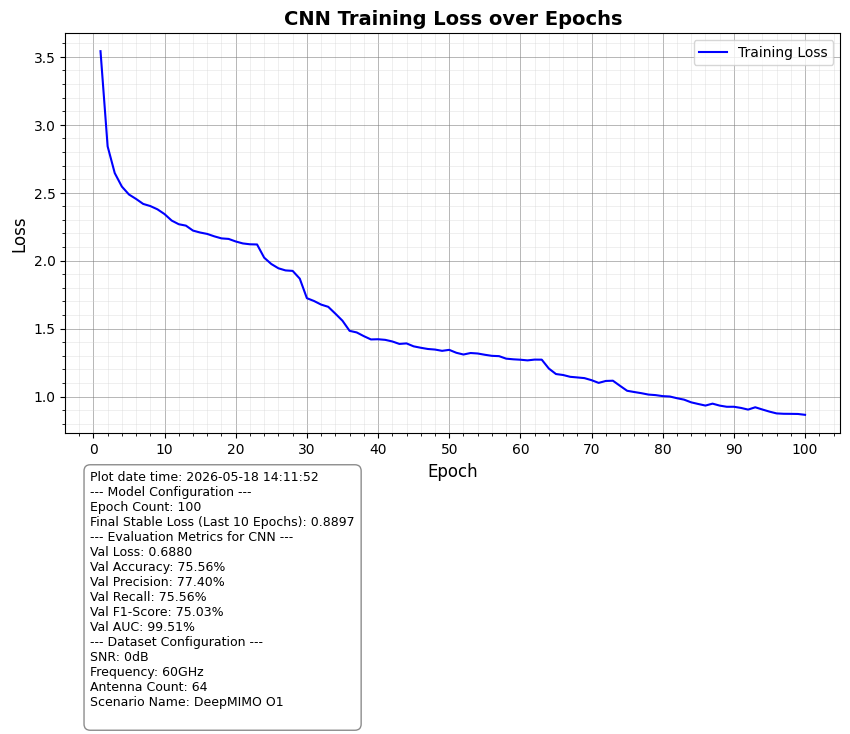

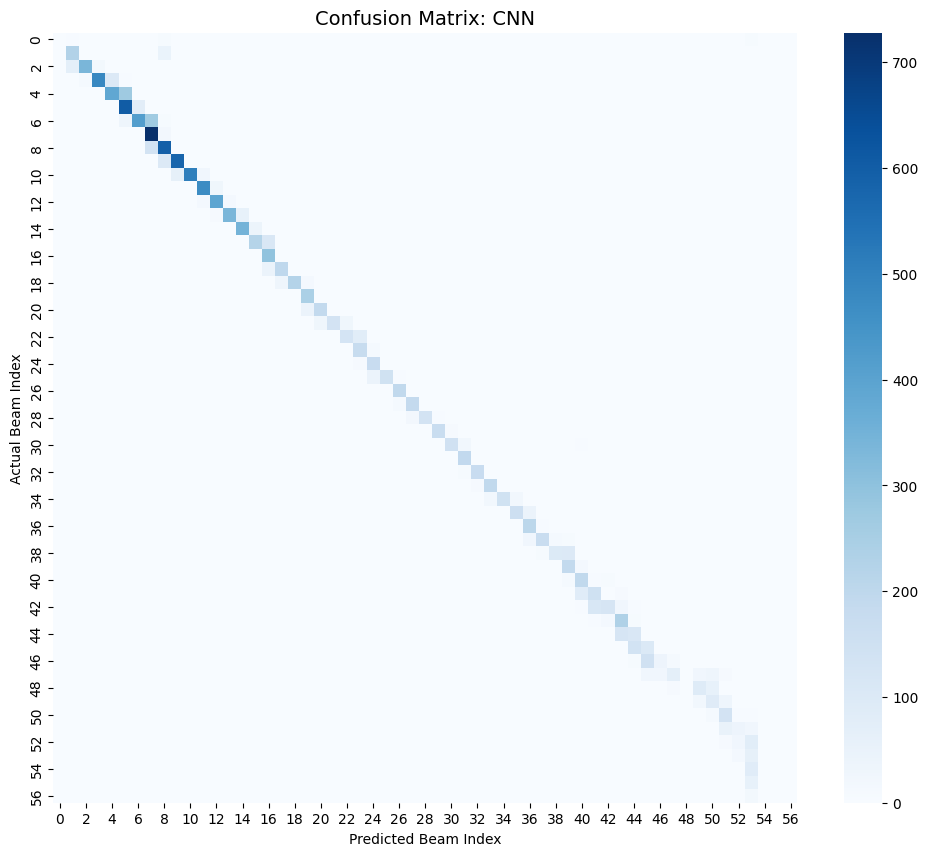

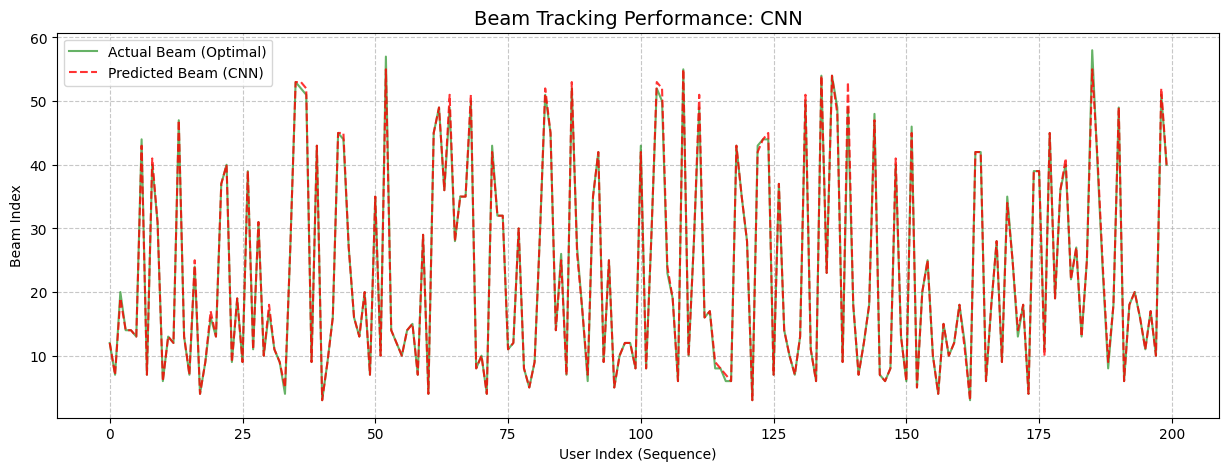

In [12]:
import evaluate as ev
import visualizer as vis

model.load_state_dict(torch.load(f'best_{ai_model}_model.pth'))

ds_config = {
    'snr': snr,
    'scenario': scenario,
    'frequency': frequency,
    'antennas': antennas
}  

# 1. รันการวัดผลและเก็บค่า raw data
mimo_results = ev.evaluate_performance(model, test_loader, device, criterion, ai_model)

# 2. วาดกราฟ Loss (อันเดิม)
vis.plot_training_loss(train_losses, mimo_results, ds_config)

# 3. วาดกราฟ Confusion Matrix (อันใหม่)
# หมายเหตุ: คุณต้องส่ง all_actuals และ all_preds ที่เก็บมาจากการรันเข้าฟังก์ชันนี้
vis.plot_confusion_matrix(mimo_results['all_actuals'], mimo_results['all_preds'], ai_model)

# 4. วาดกราฟ Beam Tracking (อันใหม่)
vis.plot_beam_tracking(mimo_results['all_actuals'], mimo_results['all_preds'], ai_model)